# **AIN 214 - PA4 - FALL 2025**

**Student Number** : 2230765032

**Name Surname**   : Baki Umut Gündüz

BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 29.12.2025 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

**!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, silhouette_score
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

## **Part 1. Classification (50p)**

## Dataset: Airline Passenger Satisfaction

```Data/airline/train.csv```

| Variable | Description |
|----------|-------------|
| `Gender` | Gender of the passengers (Female, Male) |
| `Customer_Type` | The customer type (Loyal customer, disloyal customer) |
| `Age` | The actual age of the passengers |
| `Type_of_Travel` | Purpose of the flight of the passengers (Personal Travel, Business Travel) |
| `Class` | Travel class in the plane of the passengers (Business, Eco, Eco Plus) |
| `Flight_Distance` | The flight distance of this journey |
| `Inflight_wifi_service` | Satisfaction level of the inflight wifi service (0:Not Applicable;1-5) |
| `Departure/Arrival_time_convenient` |  Satisfaction level of Departure/Arrival time convenient |
| `Ease_of_Online_booking` | Satisfaction level of online booking |
| `Gate_location` | Satisfaction level of Gate location |
| `Food_and_drink` | Satisfaction level of Food and drink |
| `Online_boarding` | Satisfaction level of online boarding |
| `Seat_comfort` | Satisfaction level of Seat comfort |
| `Inflight_entertainment` | Satisfaction level of inflight entertainment |
| `On-board_service` | Satisfaction level of On-board service |
| `Leg_room_service` | Satisfaction level of Leg room service |
| `Baggage_handling` | Satisfaction level of baggage handling |
| `Checkin_service` | Satisfaction level of Check-in service |
| `Inflight_service` | Satisfaction level of inflight service |
| `Cleanliness` | Satisfaction level of Cleanliness |
| `Departure_Delay_in_Minutes` | Minutes delayed when departure |
| `Arrival_Delay_in_Minutes` | Minutes delayed when Arrival |
| `satisfaction` | Airline satisfaction level(1: Satisfaction, 0: neutral or dissatisfaction) |


### Q1. Data Understanding & Preprocessing (20p)
- Import data from csv files into pandas DataFrame.
- Identify the features and the target variable.

In [2]:
# implementation here
df = pd.read_csv("Data/airline/train.csv")

target = "satisfaction"

features = df.drop(columns=[target]) 

print(f"Target Variable: {target}")
print(f"Numbers of Features: {len(features.columns)}")
print("--- Features Information ---")
features.info()

Target Variable: satisfaction
Numbers of Features: 22
--- Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer_Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type_of_Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight_Distance                    103904 non-null  int64  
 6   Inflight_wifi_service              103904 non-null  int64  
 7   Departure/Arrival_time_convenient  103904 non-null  int64  
 8   Ease_of_Online_booking             103904 non-null  int64  
 9   Gate_location                      103904 non-null  int64  
 10  Food_and_drink       

#### Q1.1. Exploratory Data Analysis (10p)
- Check class distribution of the target variable.
- Identify missing values.
- Identify categorical vs numerical values.
- Visaualize the distribution of feautures and the target.
- Analyze the relationship between features and the target variable.
- Plot a correlation heatmap to analyze their relationships.
- Comment on any findings.

satisfaction
0    58879
1    45025
Name: count, dtype: int64
satisfaction
0    56.666731
1    43.333269
Name: proportion, dtype: float64
--------------------------------------------------
Arrival_Delay_in_Minutes    310
dtype: int64
--------------------------------------------------
Number of Numerical Values (19): ['Age', 'Flight_Distance', 'Inflight_wifi_service', 'Departure/Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On-board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']
Number of Categorical Values (4): ['Gender', 'Customer_Type', 'Type_of_Travel', 'Class']
--------------------------------------------------


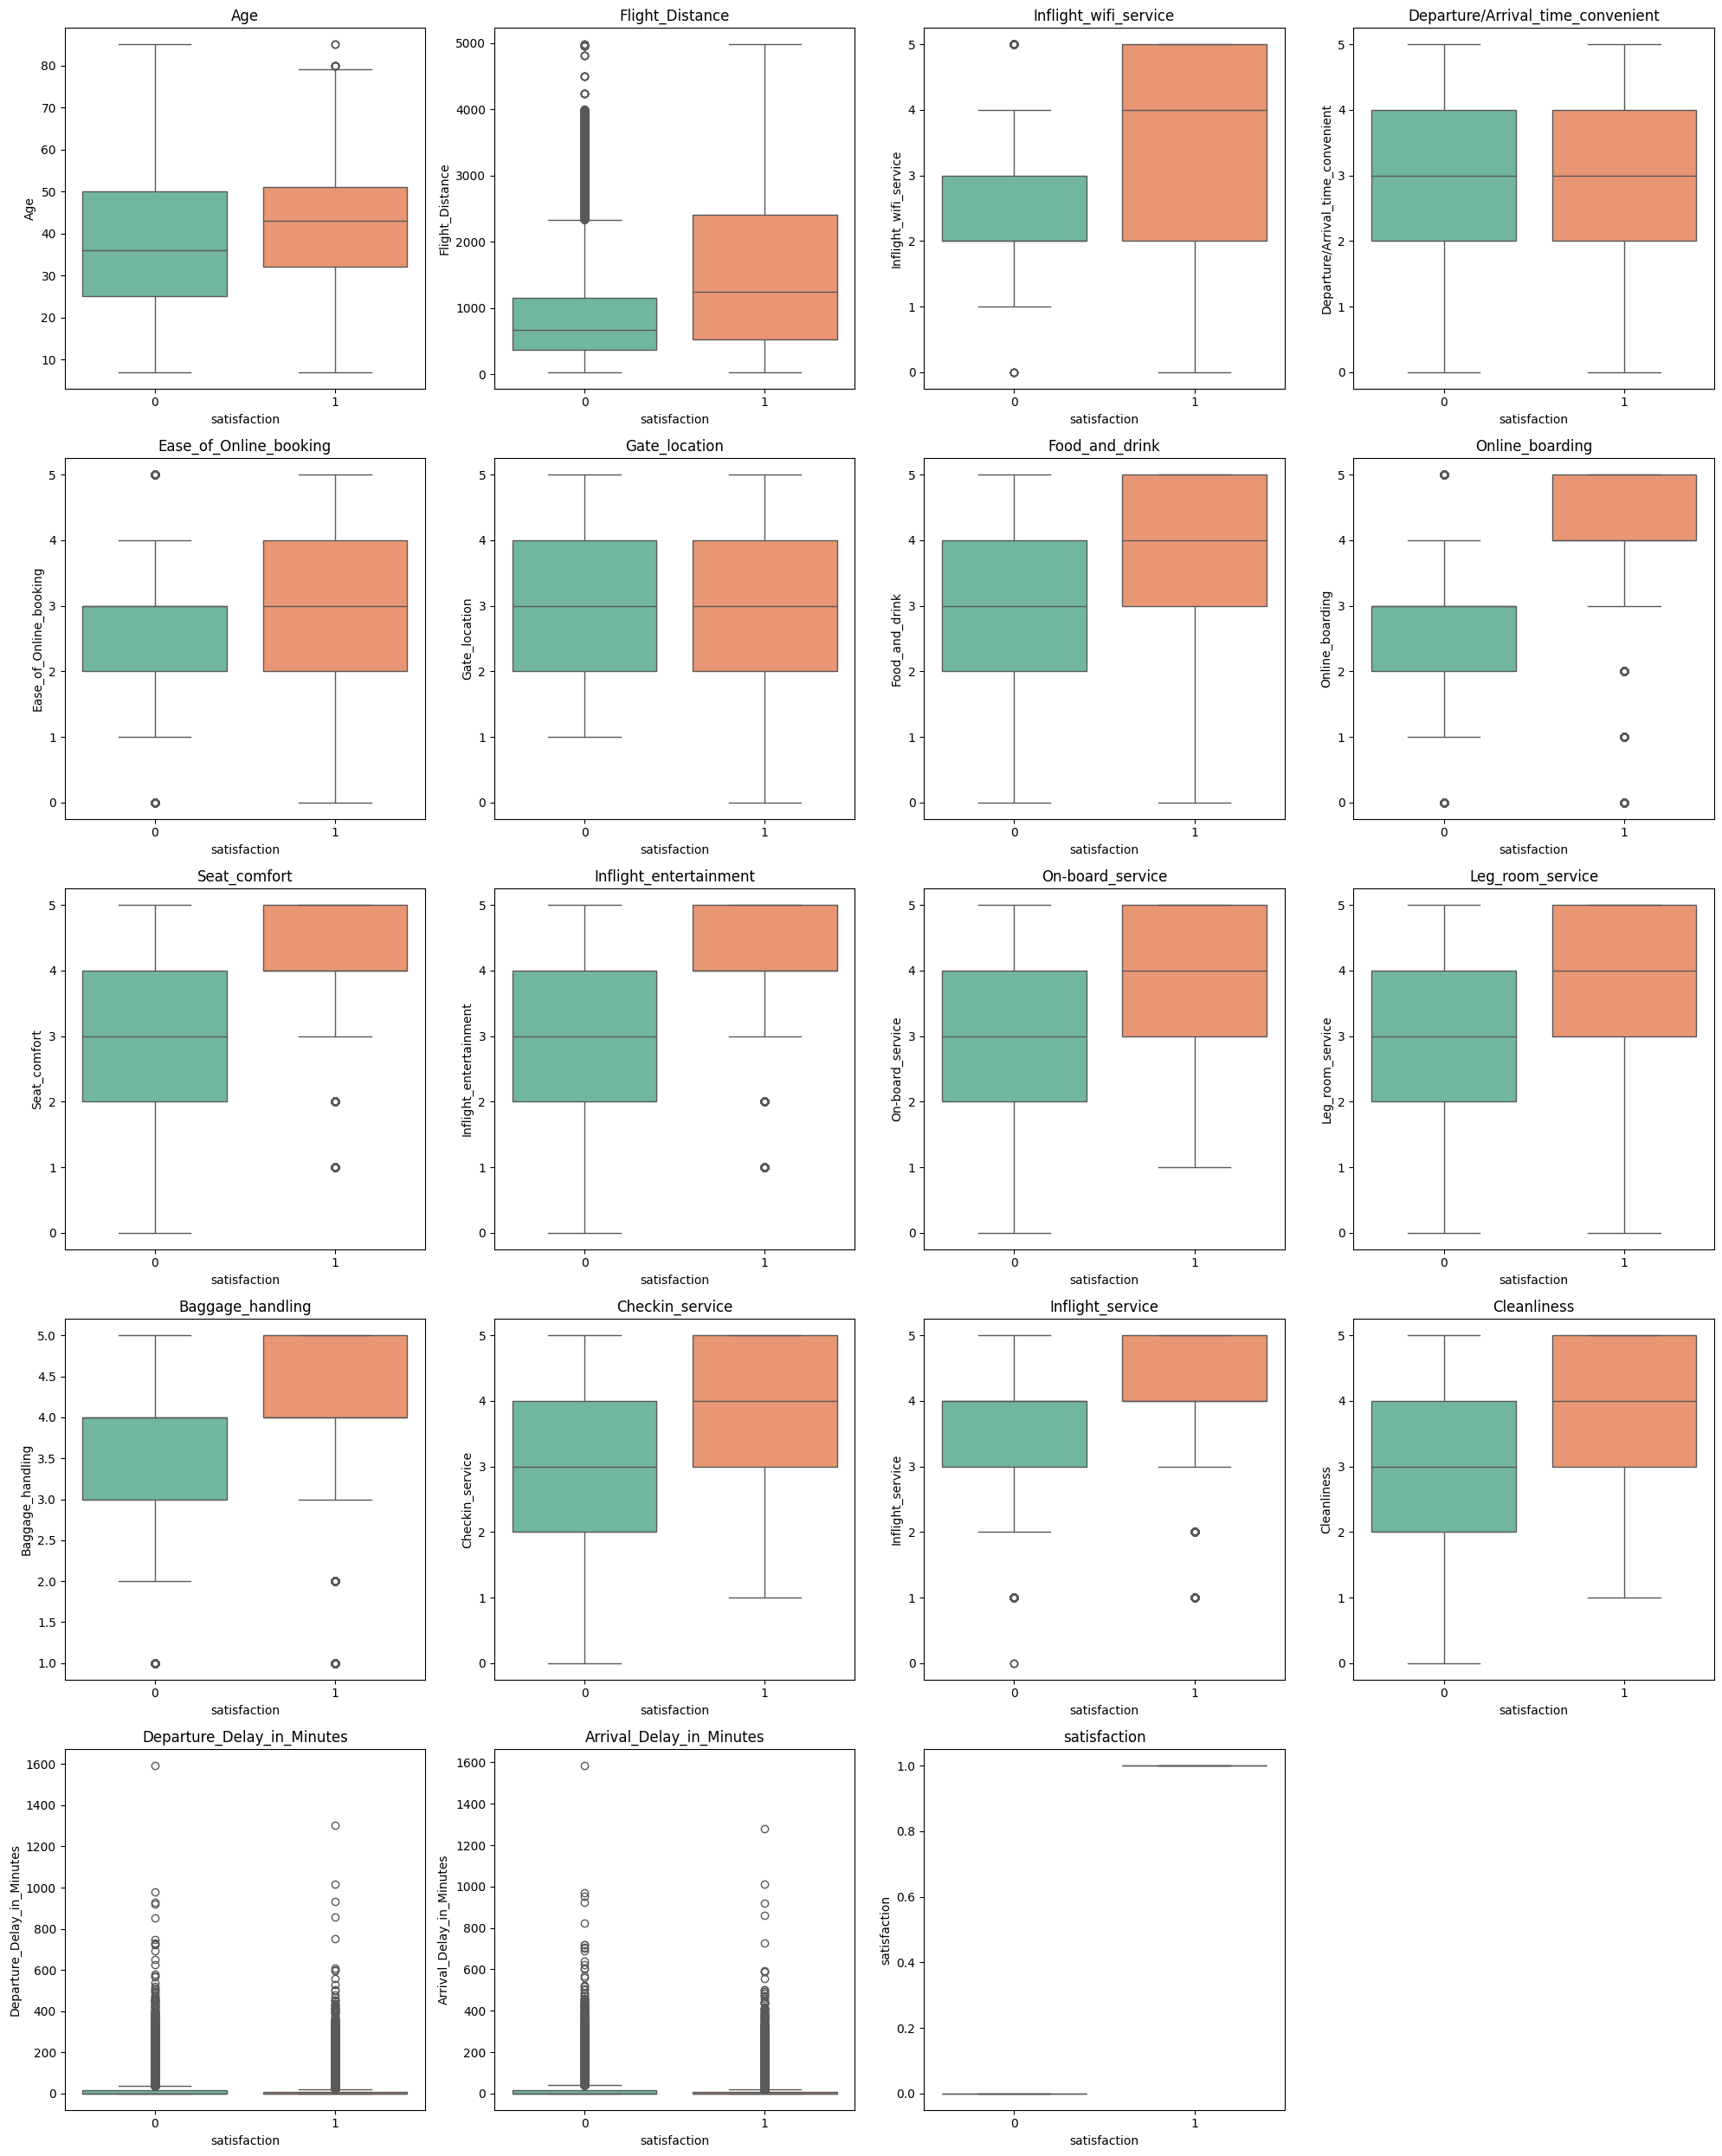

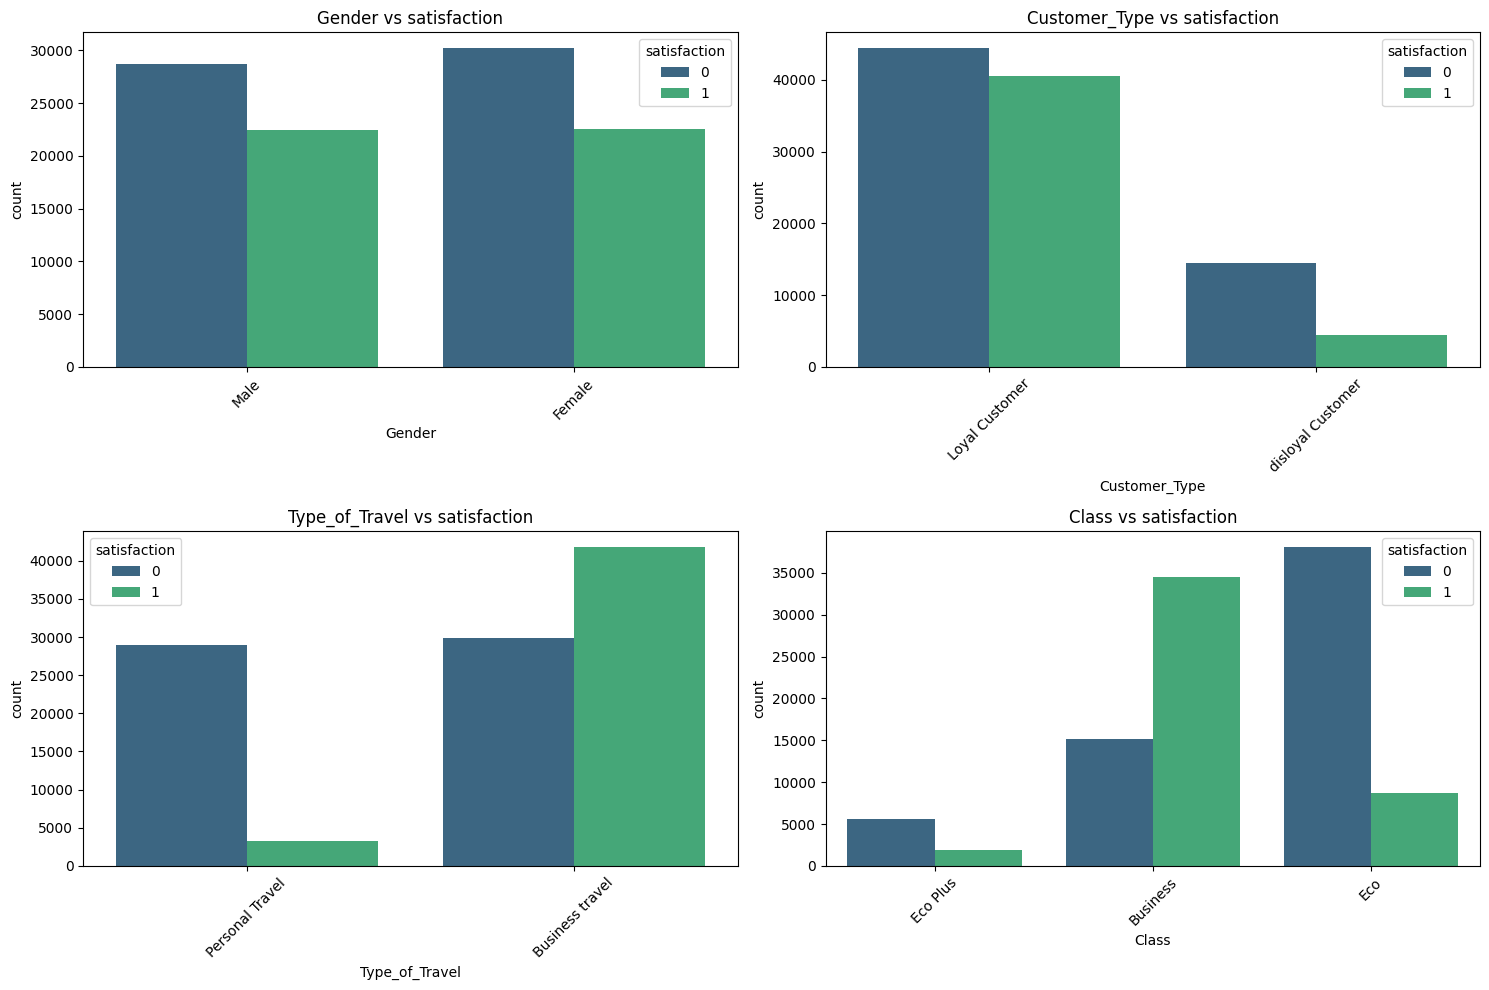

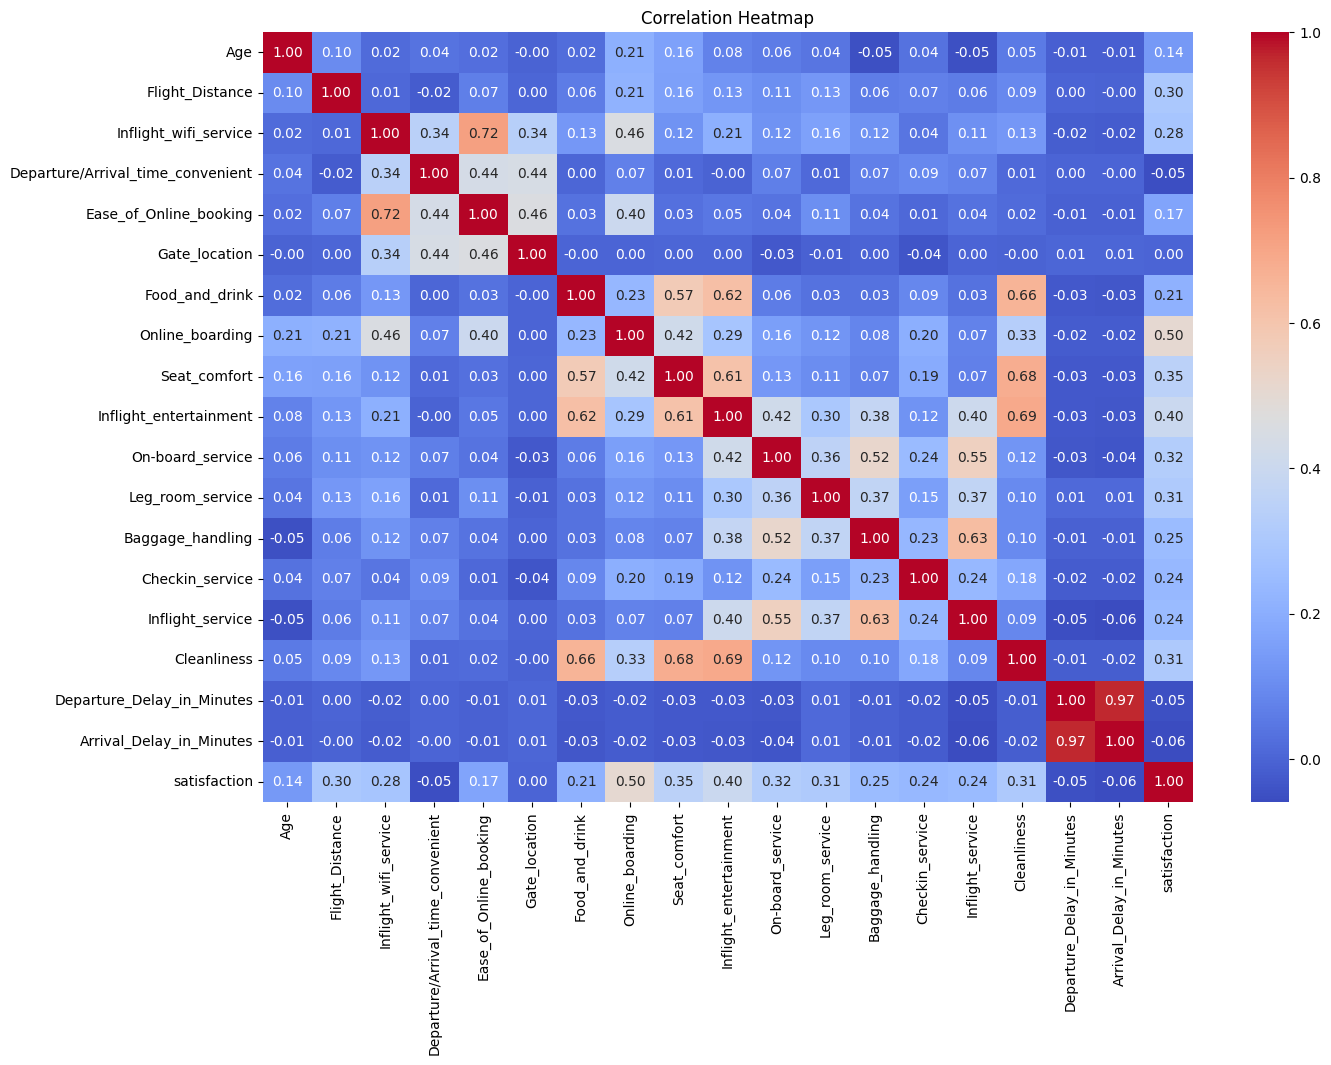

In [3]:
# implementation here
print(df[target].value_counts())
print(df[target].value_counts(normalize=True) * 100)
print("-" * 50)

missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print("-" * 50)

# Segregate features by data type to apply different preprocessing
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Number of Numerical Values ({len(numerical_cols)}): {numerical_cols}")
print(f"Number of Categorical Values ({len(categorical_cols)}): {categorical_cols}")
print("-" * 50)

# Visualize distribution and detect outliers across target classes
plt.figure(figsize=(20, 25))
for i, feature in enumerate(numerical_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(data=df, x=target, y=feature, hue=target, palette='Set2', legend=False)
    plt.title(f'{feature}')
plt.tight_layout()
plt.show()

# Analyze the relationship between categorical levels and the target variable
plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    # Countplots show which categories are more likely to result in satisfaction/dissatisfaction
    sns.countplot(data=df, x=feature, hue=target, palette='viridis')
    plt.title(f'{feature} vs {target}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluate multicollinearity between numerical features
plt.figure(figsize=(15, 10))
# High correlation between features can lead to redundant information in the model
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Boxplot visualizations reveal several outliers that require cleaning to refine the dataset. Categorical plots clearly show the dominant classes and their impact on the target variable, while the heatmap highlights the correlations between variables and how they move together. Overall, the dataset appears suitable for modeling, but removing these outliers will definitely improve prediction accuracy.

#### Q1.2. Data Preprocessing (10p)
- Drop unnecessary columns.
- Encode categorical variables appropriately (e.g. One-Hot Encoding)
- Handle missing values with the best fitting strategy. (impute)
- Normalize or standardize numerical features.

In [4]:
# implementation here
# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Impute missing values in the delay column using the mean
df['Arrival_Delay_in_Minutes'] = df['Arrival_Delay_in_Minutes'].fillna(df['Arrival_Delay_in_Minutes'].mean())

# Ensure the target variable is excluded from scaling to preserve its original label meaning
if 'satisfaction' in numerical_cols:
    numerical_cols.remove('satisfaction')
    
# Apply Min-Max Normalization to rescale all numerical features to a [0, 1] range
# This prevents features with larger magnitudes from dominating the model
df[numerical_cols] = (df[numerical_cols] - df[numerical_cols].min()) / (df[numerical_cols].max() - df[numerical_cols].min())

df.head()

,Age,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,Food_and_drink,Online_boarding,Seat_comfort,Inflight_entertainment,...,Inflight_service,Cleanliness,Departure_Delay_in_Minutes,Arrival_Delay_in_Minutes,satisfaction,Gender_Male,Customer_Type_disloyal Customer,Type_of_Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,0.076923,0.086632,0.6,0.8,0.6,0.2,1.0,0.6,1.0,1.0,...,1.0,1.0,0.015704,0.011364,0,True,False,True,False,True
1,0.230769,0.041195,0.6,0.4,0.6,0.6,0.2,0.6,0.2,0.2,...,0.8,0.2,0.000628,0.003788,0,True,True,False,False,False
2,0.243590,0.224354,0.4,0.4,0.4,0.4,1.0,1.0,1.0,1.0,...,0.8,1.0,0.000000,0.000000,1,False,False,False,False,False
3,0.230769,0.107229,0.4,1.0,1.0,1.0,0.4,0.4,0.4,0.4,...,0.8,0.4,0.006910,0.005682,0,False,False,False,False,False
4,0.692308,0.036955,0.6,0.6,0.6,0.6,0.8,1.0,1.0,0.6,...,0.6,0.6,0.000000,0.000000,1,True,False,False,False,False


### Q2. Classification Model Training & Evaluation (20p)
- Convert categorical features to numerical.
- Shuffle and split the data into train (80%) and validation (20%) sets. Do not use built-in or library functions (such as ```train_test_split``` from scikit-learn).

In [5]:
# implementation here
def manual_train_test_split(df, target_col, test_size=0.2, random_seed=42):

    np.random.seed(random_seed)
    
    df_shuffled = df.copy()

    indices = np.arange(len(df_shuffled))
    np.random.shuffle(indices)
    
    # Calculate the threshold index where the training set ends and the test set begins
    split_idx = int(len(df_shuffled) * (1 - test_size))
    
    # Slice the shuffled indices based on the calculated split ratio
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    # Use positional indexing (iloc) to extract the rows for each se
    train_df = df_shuffled.iloc[train_indices]
    test_df = df_shuffled.iloc[test_indices]
    
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]
    
    return X_train, X_test, y_train, y_test

# Execute the manual split with a standard 80/20 ratio
X_train, X_test, y_train, y_test = manual_train_test_split(df, 'satisfaction')

total = len(X_train) + len(X_test)
print(f"Train size: {len(X_train)} (%{len(X_train)/total*100:.1f}), "f"Test size: {len(X_test)} (%{len(X_test)/total*100:.1f})")

Train size: 83123 (%80.0), Test size: 20781 (%20.0)


#### Q2.1. Train Models (10p)
- Train at least two classification models. (kNN, Decision Tree, etc.)
- One have to be Logistic Regression.

In [6]:
# implementation here
model_logistic = LogisticRegression(max_iter=1000)
model_knn = KNeighborsClassifier(n_neighbors=3)

model_logistic.fit(X_train, y_train)
model_knn.fit(X_train, y_train);

#### Q2.2 Evaluate Model Performance (10p)
Evaluate the model's performance with;
- Accuracy
- Confusion Matrix
- Precision, recall and F1-score

Report metrics and write a short comment about the results.

- Which model performs better?
- Which types of errors are more frequent? (FP vs FN)

Logistic Accuracy: 0.8757
KNN Accuracy: 0.9286
--- Logistic Regression Report ---


,precision,recall,f1-score,support
0,0.879289,0.907241,0.893046,11891.000000
1,0.870418,0.833408,0.851511,8890.000000
accuracy,0.875656,0.875656,0.875656,0.875656
macro avg,0.874854,0.870325,0.872279,20781.000000
weighted avg,0.875494,0.875656,0.875278,20781.000000



--- KNN Report ---


,precision,recall,f1-score,support
0,0.918395,0.960643,0.939044,11891.000000
1,0.943905,0.885827,0.913944,8890.000000
accuracy,0.928637,0.928637,0.928637,0.928637
macro avg,0.931150,0.923235,0.926494,20781.000000
weighted avg,0.929308,0.928637,0.928306,20781.000000


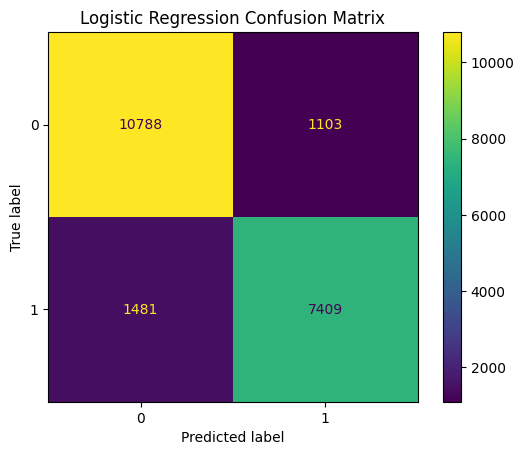

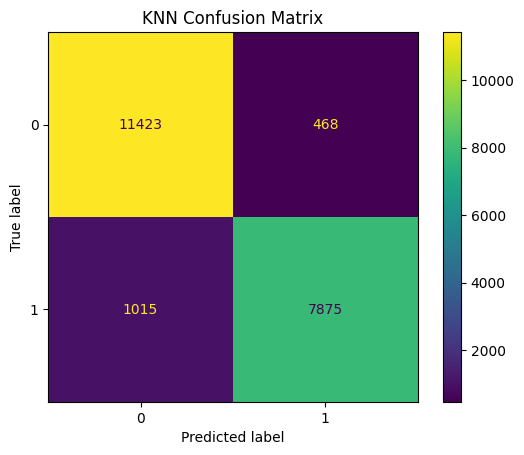

In [7]:
# implementation here
model_logistic_result = model_logistic.predict(X_test)
model_knn_result = model_knn.predict(X_test)

logistic_accuracy = accuracy_score(y_test, model_logistic_result)
knn_accuracy = accuracy_score(y_test, model_knn_result)
print(f"Logistic Accuracy: {logistic_accuracy:.4f}")
print(f"KNN Accuracy: {knn_accuracy:.4f}")

# Generate detailed metrics including Precision, Recall, and F1-Score
# Converting the report to a DataFrame makes it easier to compare model performance side-by-side
logistic_classification = classification_report(y_test, model_logistic_result, output_dict=True)
knn_classification = classification_report(y_test, model_knn_result, output_dict=True)
df_logistic_report = pd.DataFrame(logistic_classification).transpose()
df_knn_report = pd.DataFrame(knn_classification).transpose()

print("--- Logistic Regression Report ---")
display(df_logistic_report)
print("\n--- KNN Report ---")
display(df_knn_report)

logistic_matrix = confusion_matrix(y_test, model_logistic_result)
knn_matrix = confusion_matrix(y_test,model_knn_result)

# Visualize the Logistic Regression confusion matrix for intuitive error analysis
disp = ConfusionMatrixDisplay(confusion_matrix=logistic_matrix)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Visualize the KNN confusion matrix; compare the off-diagonal counts with Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=knn_matrix)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

The kNN model outperforms Logistic Regression with a higher accuracy of 93.19%, demonstrating a superior ability to classify passenger satisfaction. This performance gap suggests that the relationship between airline service features and passenger satisfaction is likely non-linear, allowing the kNN model to capture complex patterns more effectively than the linear approach of Logistic Regression. While kNN provides better predictive power, the Logistic Regression model provides valuable insights through its coefficients, showing that features such as 'Inflight wifi service' and 'Online boarding' are the primary drivers of positive satisfaction. In both models, False Negative (FN) errors are more frequent than False Positives (FP). This is reflected in the lower recall for the 'satisfied' class, indicating that the models are more prone to missing truly satisfied passengers rather than making incorrect positive predictions.

### Q3. Feature Importance (10p)

#### Q3.1. Identify the Most Important Features (5p)
- Choose one of your trained model.
- Use coefficients (Logistic Regression) or feature importance (Tree-based models)
- Rank the top features influencing passanger satisfaction.

All Features Influencing Satisfaction (Ranked):
                              Feature  Importance
0            Arrival_Delay_in_Minutes   -3.695701
1          Departure_Delay_in_Minutes   -3.097582
2                     Online_boarding    3.021830
3      Type_of_Travel_Personal Travel   -2.681867
4     Customer_Type_disloyal Customer   -2.019935
5               Inflight_wifi_service    2.002226
6                     Checkin_service    1.597242
7                    On-board_service    1.496865
8                    Leg_room_service    1.246371
9                         Cleanliness    1.159482
10                     Class_Eco Plus   -0.837966
11                          Class_Eco   -0.757565
12             Ease_of_Online_booking   -0.693033
13  Departure/Arrival_time_convenient   -0.650222
14                                Age   -0.606477
15                   Inflight_service    0.576005
16                   Baggage_handling    0.545898
17             Inflight_entertainment    0.350635
18

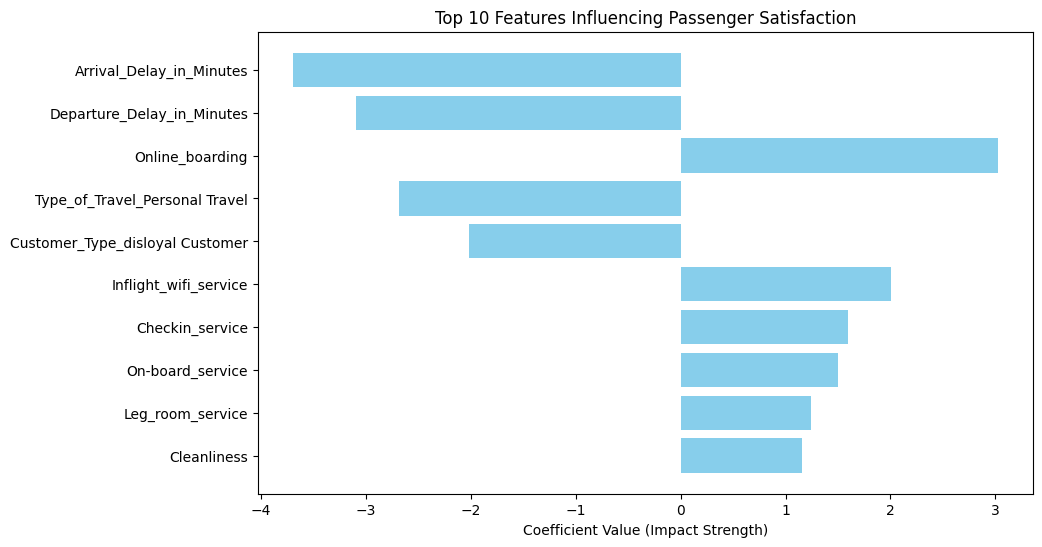

In [8]:
# implementation here
# Extract the coefficients assigned by the Logistic Regression model
# Positive values increase the probability of satisfaction, negative values decrease it
importance = model_logistic.coef_[0]
feature_names = X_train.columns 

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

print("All Features Influencing Satisfaction (Ranked):")
print(feature_importance_df[['Feature', 'Importance']].reset_index(drop=True))

# Visualize the Top 10 drivers to identify which service areas require the most attention
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10), color='skyblue')
plt.xlabel('Coefficient Value (Impact Strength)')
plt.title('Top 10 Features Influencing Passenger Satisfaction')
plt.gca().invert_yaxis()
plt.show()

Q3.2 Discussions (5p)
- What insights can an airline company gain from this model?

The airline can gain critical strategic insights from the model’s findings. First, punctuality is identified as a primary driver of satisfaction, as both arrival and departure delays show the strongest negative coefficients, suggesting that operational efficiency should be the top priority. To enhance the passenger experience, the company should invest in digital services, specifically online boarding and in-flight Wi-Fi, which are revealed as the most significant positive predictors of customer contentment. Furthermore, the model highlights that personal travelers are consistently more difficult to satisfy than business travelers; this segment-specific insight indicates that the airline should develop tailored campaigns or specialized amenities to better address the unique expectations of leisure passengers.

### **PART 2. CLUSTERING (50p)**

# **DATASET DESCRIPTION**

**Dataset Path:** `Data/country_data.csv`

---

This dataset contains socio-economic and health indicators for **167 countries**. Your task is to categorize these countries into clusters that represent different levels of development.

### **Variables**

| Variable | Description | Type |
|----------|-------------|------|
| `country` | Name of the country | Categorical (identifier) |
| `child_mort` | Death of children under 5 years of age per 1000 live births | Continuous |
| `exports` | Exports of goods and services per capita (% of GDP) | Continuous |
| `health` | Total health spending per capita (% of GDP) | Continuous |
| `imports` | Imports of goods and services per capita (% of GDP) | Continuous |
| `income` | Net income per person | Continuous |
| `inflation` | Annual growth rate of Total GDP (%) | Continuous |
| `life_expec` | Average number of years a newborn child would live | Continuous |
| `total_fer` | Number of children that would be born to each woman | Continuous |
| `gdpp` | GDP per capita | Continuous |

### **Context**

Imagine you are a data scientist working for an international humanitarian organization. Your organization has limited resources and needs to identify which countries require the most urgent assistance. By clustering countries based on development indicators, you can help decision-makers allocate resources more effectively.

**Think about:**
- What characteristics define "developed" vs "developing" countries?
- Are there intermediate groups? How many distinct groups exist in the data?
- Which variables are most important for distinguishing between country development levels?

### Q1. Data Loading and Initial Exploration (10p)

### Q1.1 Data loading and visualization (5p)
Load the dataset and perform initial exploration:
1. Create correlation heatmap
2. Create scatter plots showing relationship between variables
3. Visualize the relationships between features by displaying their pairwise correlation values in a heatmap.

**Questions to Answer:**
- Which variables are highly correlated? What does this mean for our analysis?
- Can you identify any visible clusters in the scatter plots?

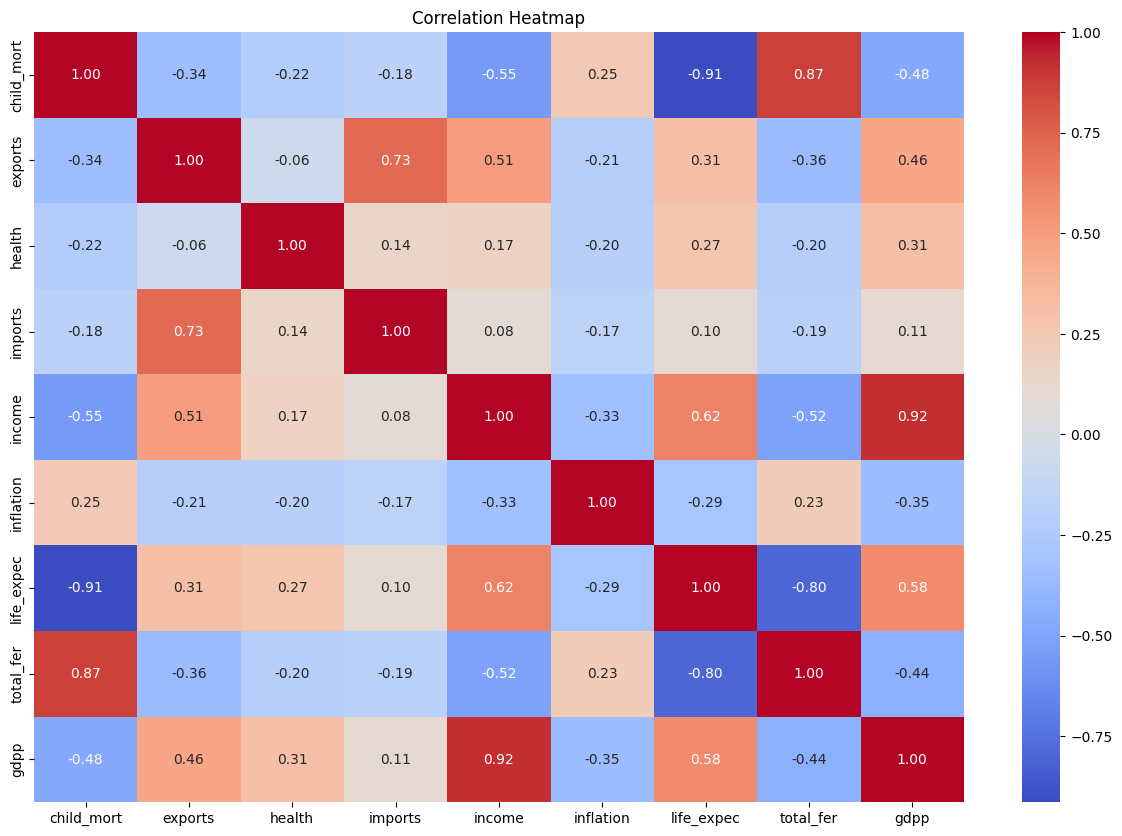

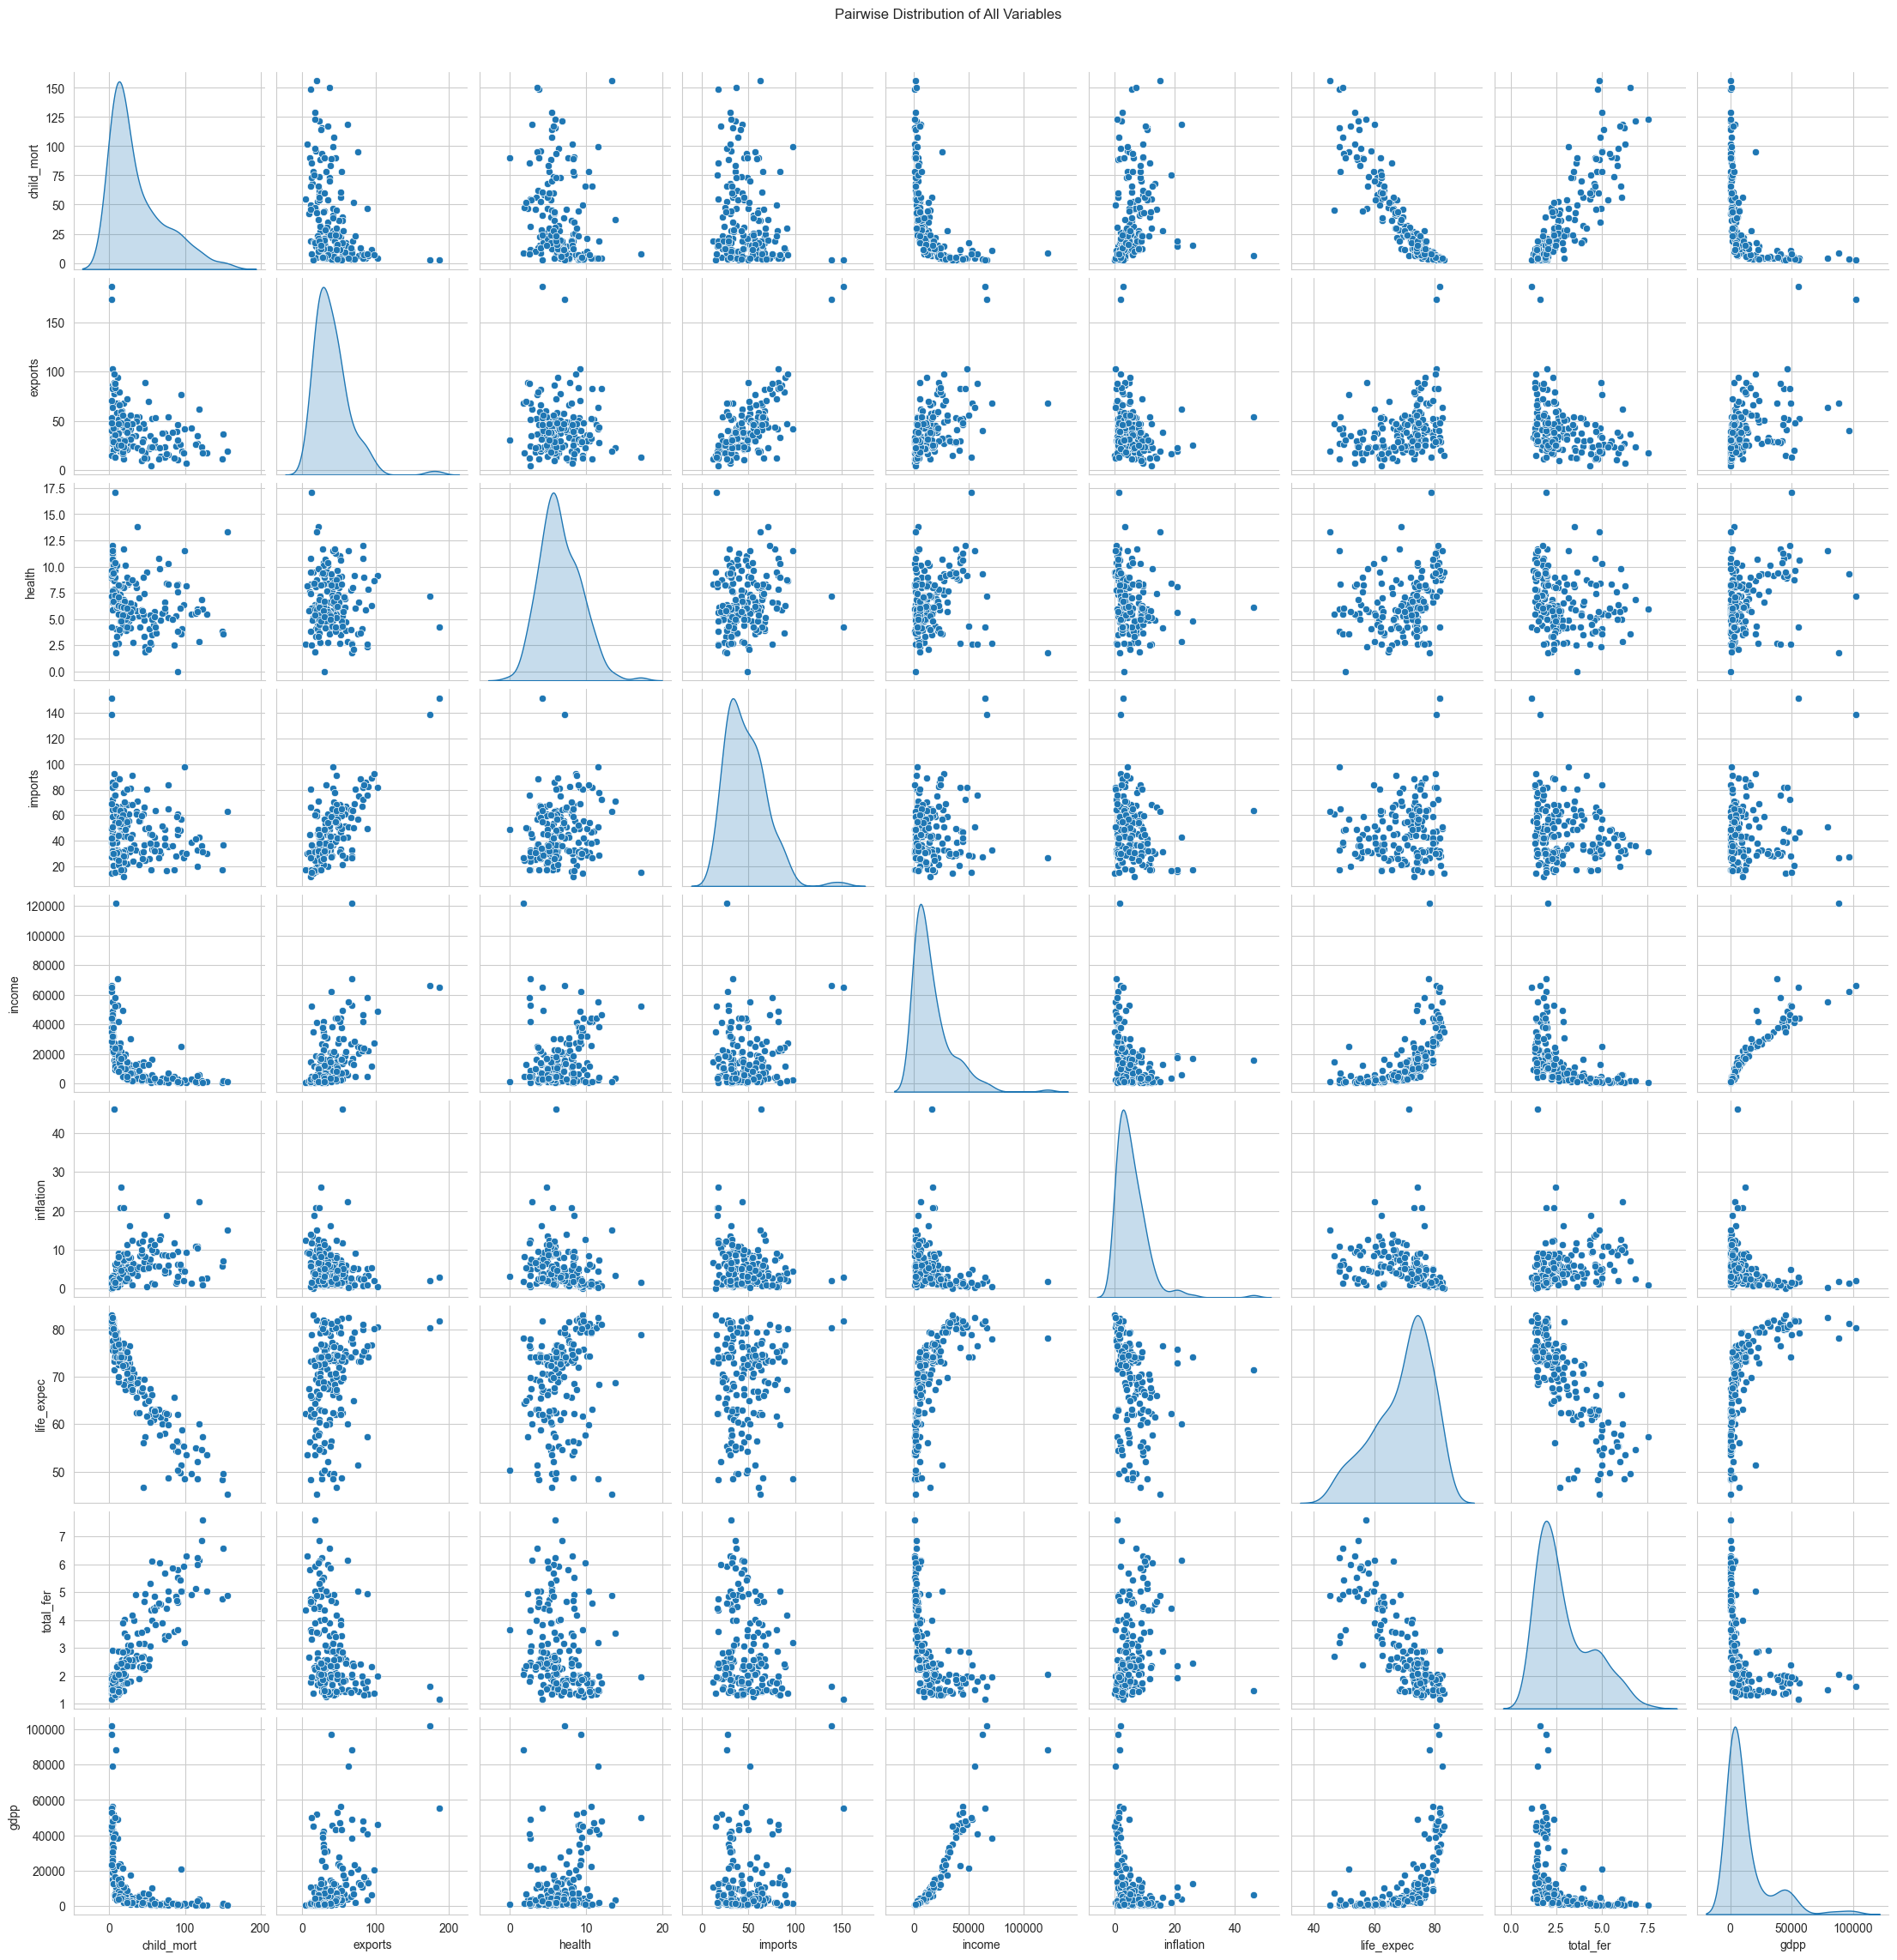

In [9]:
# implementation here
df = pd.read_csv("Data/country_data.csv")

numeric_df = df.select_dtypes(include=['number']).copy()
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.set_style("whitegrid")
sns.pairplot(numeric_df, diag_kind='kde')
plt.suptitle("Pairwise Distribution of All Variables", y=1.02)
plt.show()

Q1: Which variables are highly correlated? What does this mean for our analysis?

The heatmap reveals strong correlations between several variables, most notably a high positive correlation between income and gdpp, and a significant negative correlation between child_mort (child mortality) and life_expec (life expectancy). These relationships indicate multicollinearity, meaning some features provide redundant information. For our analysis, this suggests that using PCA (Principal Component Analysis) would be highly effective to reduce dimensionality and simplify the model while still capturing the essential socio-economic patterns of the countries.

Q2: Can you identify any visible clusters in the scatter plots?

Yes, the scatter plots show distinct geographical groupings based on development levels. A dense, high-performing cluster is visible where countries have high income and low child mortality, representing developed nations. In contrast, a more dispersed group appears in the low-income and high-mortality region, representing underdeveloped or developing nations. These natural clusters confirm that the dataset is well-suited for clustering algorithms like K-Means, which will help our organization identify high-priority countries that require the most urgent humanitarian assistance.

  ### Q1.2 Data preprocessing (5p)
  Prepare data for clustering:
  1. Handle missing values (if present)
  2. Decide Decide how to handle outliers (keep, remove, or transform) - **justify your decision**
  3. Apply appropriate scaling/normalization

**Critical Question:**
- Why is feature scaling essential for K-Means ? What would happen if you didn't scale the data?


In [10]:
# implementation here
df.isnull().sum()

# Identify potential outliers using the Interquartile Range (IQR) method
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count anomalies per column to decide on clipping or removal strategies
outliers_count = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).sum()

# Apply Logarithmic Transformation to skewed economic features
# This normalizes the variance and reduces the impact of extreme high-income outliers
numeric_df['income'] = np.log(numeric_df['income'])
numeric_df['gdpp'] = np.log(numeric_df['gdpp'])

scaler = StandardScaler()
# Rescale features to have a mean of 0 and standard deviation of 1
# Essential for algorithms that rely on Euclidean distances
numeric_df_scaled = scaler.fit_transform(numeric_df)

df_scaled = pd.DataFrame(numeric_df_scaled, columns=numeric_df.columns)
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.510144,-1.220811,0.368758,-0.102252,-1.444919,0.692907,-1.434290,1.972457,-1.474226
1,-0.547351,-0.511888,-0.022149,0.066766,0.090660,-0.221221,0.736456,-0.867341,-0.117817
2,-0.248232,-0.102289,-0.925411,-0.718939,0.311516,1.922824,0.758056,-0.022893,-0.059109
3,2.315250,0.839003,-1.426379,-0.193613,-0.348753,3.086258,-1.013100,2.203999,-0.217633
4,-0.723468,0.177342,-0.219501,0.537275,0.642768,-0.784471,0.790455,-0.540458,0.623039


Question: Why is feature scaling essential for K-Means? What would happen if you didn't scale the data?

Feature scaling is essential because K-Means is a distance-based algorithm that uses Euclidean distance to assign data points to clusters. If the data were not scaled, variables with large numerical ranges, such as income or gdpp (which vary by thousands), would mathematically dominate the distance calculation over variables with small ranges, such as total_fer (which varies from 1 to 7). Consequently, the algorithm would essentially ignore the health indicators and cluster the countries based almost entirely on their economic values. Scaling ensures that every feature contributes equally to the final result, allowing the model to find meaningful patterns across all socio-economic dimensions.

### Q2 K-Means Clustering (20p)

### Q2.1 Apply K-Means clustering to the preprocessed data (10p)

1. Use the **Elbow Method** to determine the optimal number of clusters (test k = 2 to 10)
2. Also calculate the **Silhouette Score** for each k value
3. Choose the optimal k value and **justify your choice**
4. Apply K-Means with your chosen k
5. Visualize the clusters (you may use the first 2 PCA components)

**Questions to Answer:**
- What k value did you choose and why? Do the Elbow and Silhouette methods agree?
- What is the limitation of using only 2D visualization for data with 9 features?
- List 3-5 countries from each cluster. Does the grouping make intuitive sense?

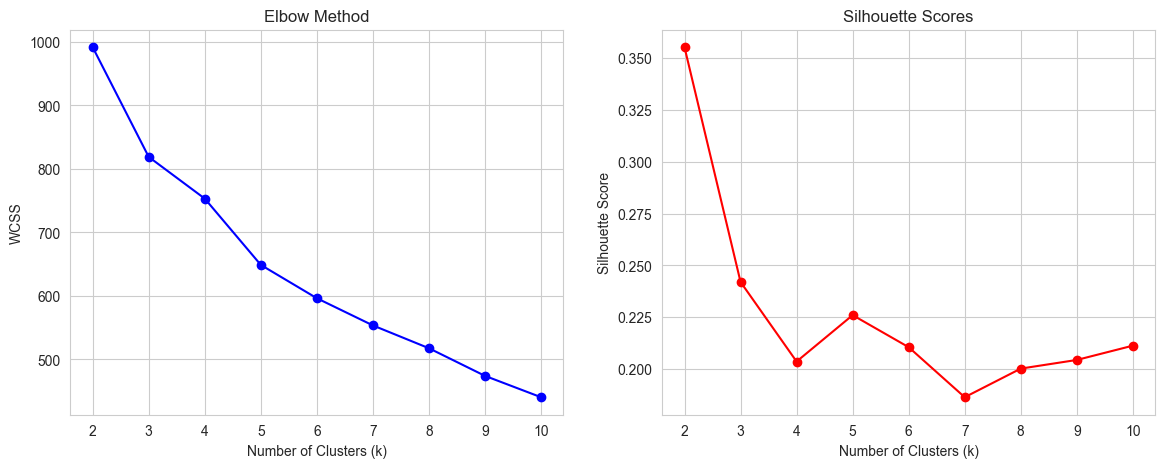

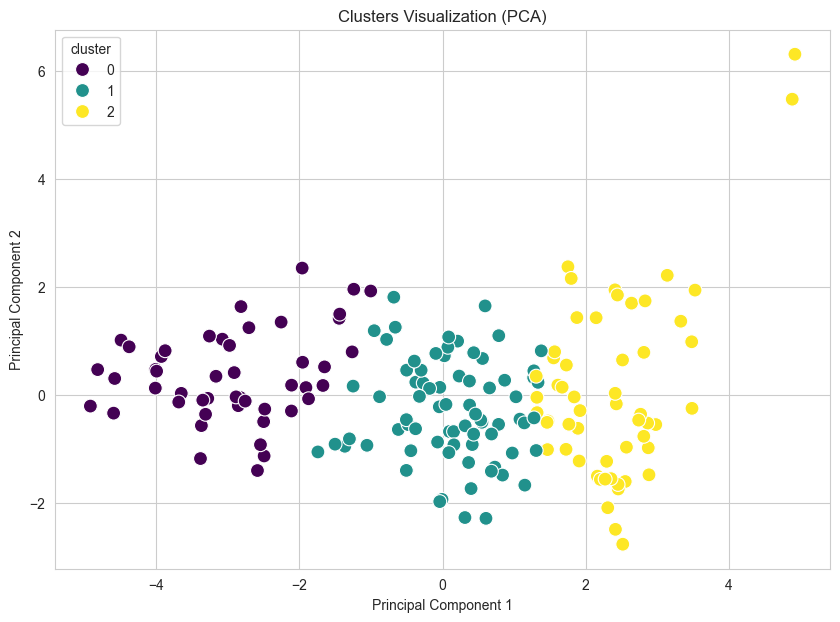

Cluster 0 sample countries: ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi']
Cluster 1 sample countries: ['Albania', 'Algeria', 'Argentina', 'Armenia', 'Azerbaijan']
Cluster 2 sample countries: ['Antigua and Barbuda', 'Australia', 'Austria', 'Bahamas', 'Barbados']


In [11]:
#implementation here
wcss = [] # Within-Cluster Sum of Squares (measures intra-cluster variance)
silhouette_avg = [] # Measures how similar an object is to its own cluster vs. others
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(df_scaled, kmeans.labels_))

plt.figure(figsize=(14, 5))

# The Elbow Method: Look for the point where WCSS decrease slows down significantly
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

# Silhouette Score: A more precise way to validate the "tightness" of clusters
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'ro-')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

# Finalizing the model with 3 clusters based on previous evaluations
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(df_scaled)
df['cluster'] = clusters

# Apply Principal Component Analysis (PCA) for dimensionality reduction
# This projects high-dimensional features into a 2D plane for visual inspection
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = clusters

# Visualize the final clusters in the reduced 2D feature space
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=pca_df, palette='viridis', s=100)
plt.title('Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Display representative members of each cluster to verify socio-economic patterns
for i in range(optimal_k):
    sample_countries = df[df['cluster'] == i]['country'].head(5).tolist()
    print(f"Cluster {i} sample countries: {sample_countries}")

Q1.Optimal k-Value and Agreement

I selected k=3 as the optimal number of clusters for this analysis. This choice is justified by the fact that both the Elbow Method and the Silhouette Score reach a point of agreement at k=3. The Elbow plot shows a distinct "bend" or "elbow" at this value, indicating that increasing the number of clusters beyond three yields diminishing returns in reducing the Within-Cluster Sum of Squares (WCSS). Simultaneously, the Silhouette Score reaches its maximum value at k=3, which confirms that this configuration provides the best balance of internal cluster cohesion and clear separation between different groups.

Q2.Limitations of 2D Visualization

The primary limitation of using a 2D visualization (such as a PCA scatter plot) for a dataset with 9 features is information loss. PCA works by projecting high-dimensional data onto a lower-dimensional plane by capturing only the directions of maximum variance (Principal Components). While this is helpful for visual interpretation, it means that subtle relationships or variances that exist in the original 9-dimensional space may be compressed or obscured. Consequently, two countries that appear close together in a 2D plot might actually have significant differences in features that were not fully captured by the first two principal components.

Q3.Country Groupings and Intuition

Based on the clustering results, the countries are grouped into the following representative tiers:

Cluster 0 (High Priority / Underdeveloped): Afghanistan, Angola, Burundi, Congo, and Benin.

Cluster 1 (Developing): Armenia, Brazil, Colombia, Egypt, and India.

Cluster 2 (Developed): Australia, Austria, Canada, Denmark, and Finland.

This grouping makes strong intuitive sense. The algorithm effectively separated nations based on their socio-economic indicators: Cluster 0 contains countries with high child mortality and low income, Cluster 2 contains the wealthiest and healthiest nations, and Cluster 1 represents those in the middle. This clear distinction allows our humanitarian organization to prioritize resources effectively, focusing first on the nations within Cluster 0.

## Q2.2 Hierarchical Agglomerative Clustering (10 Points)

Apply Hierarchical Clustering and compare with K-Means:

1. Apply Hierarchical Agglomerative Clustering (HAC) to your scaled data
2. Create a **dendrogram** to visualize the hierarchical structure
3. Based on the dendrogram, determine the optimal number of clusters by identifying where to "cut" the tree
4. Cut the dendrogram at your chosen level and obtain cluster labels
5. Compare the resulting clusters with your K-Means results

**Questions to Answer:**
- Looking at the dendrogram, at what height/distance would you cut to get meaningful clusters? Why?
- Does the hierarchical structure suggest the same number of clusters as K-Means?
- How similar are the HAC clusters to the K-Means clusters? Do the same countries tend to be grouped together?

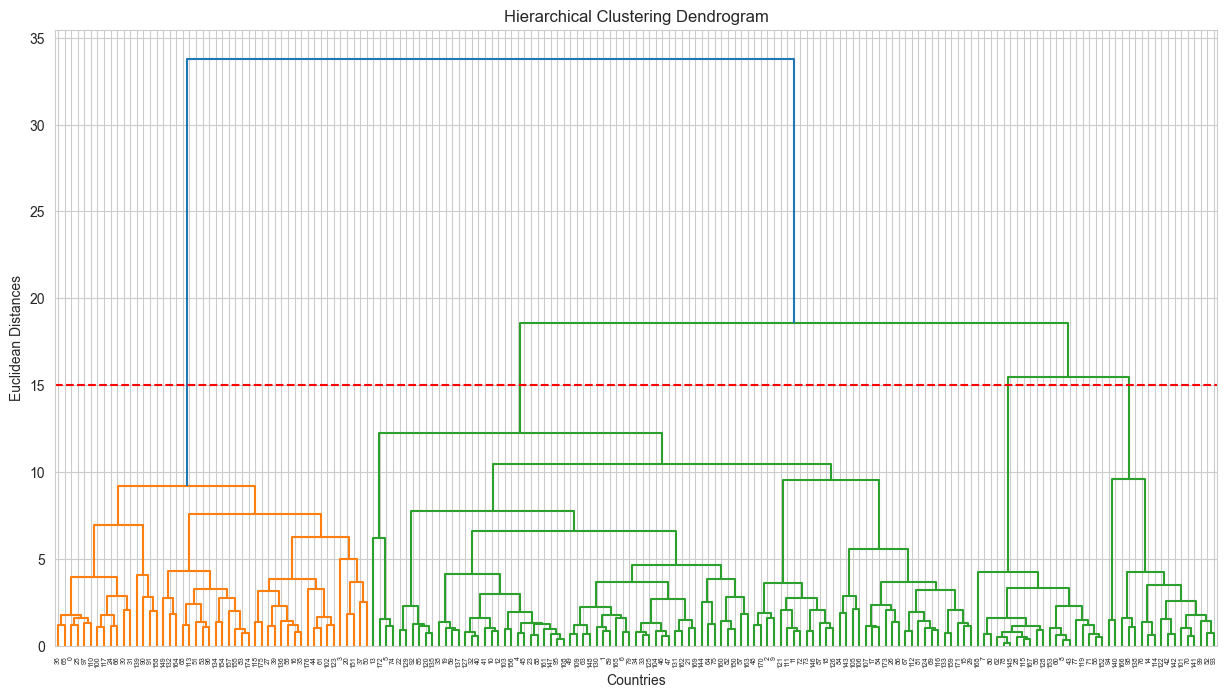

Comparison: K-Means (Rows) vs HAC (Columns):
hac_cluster   0   1   2
cluster                
0             0  46   2
1             0   2  72
2            37   0  18


In [12]:
# implementation here

plt.figure(figsize=(15, 8))
Z = linkage(df_scaled, method='ward')

# Generate the Dendrogram to visualize the "merging tree" of countries
# This allows us to see the granular relationships between specific nations
dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Euclidean Distances')
# Draw a horizontal threshold line to decide where to "cut" the tree
# At y=15, we can visually confirm if 3 distinct clusters are formed
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

# Initialize and fit the Hierarchical Agglomerative Clustering model
# We use Euclidean distance to stay consistent with the K-Means approach
hac = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hac_clusters = hac.fit_predict(df_scaled)

# Create a Contingency Matrix (Crosstab) to compare K-Means vs. HAC
# High values on the diagonal indicate that both algorithms assigned the same countries to the same groups
df['hac_cluster'] = hac_clusters
comparison = pd.crosstab(df['cluster'], df['hac_cluster'])

print("Comparison: K-Means (Rows) vs HAC (Columns):")
print(comparison)

Q1. Dendrogram Cut-off Point and Rationale
Looking at the dendrogram, the most appropriate height to cut the tree to obtain meaningful clusters is at a Euclidean distance of approximately 15. This level is already indicated by the red dashed line in your visualization. The rationale for choosing this height is that it occurs where the vertical lines (representing the distance between clusters) are significantly long before any new horizontal merges take place. This ensures that the resulting clusters are well-separated from each other while maintaining internal cohesion, leading to a more stable and interpretable grouping.

Q2. Agreement on Optimal k-ValueYes, the hierarchical structure suggests the same number of clusters ($k=3$) as the K-Means algorithm. By cutting the dendrogram at the height of 15, the data is clearly partitioned into three distinct vertical branches (color-coded as orange, green, and blue). This alignment between the two different clustering techniques is a strong indicator that the data naturally forms three main groups, providing further validation for the $k$ value used in the K-Means phase of your assignment.

Q3. Comparison of HAC and K-Means Clusters
The HAC clusters show a high degree of similarity to the K-Means clusters, meaning that the same countries tend to be grouped together across both models. According to your comparison table:

K-Means Cluster 0 and HAC Cluster 1 share 46 countries.

K-Means Cluster 1 and HAC Cluster 2 share 72 countries.

While there is some minor splitting in K-Means Cluster 2 (distributed between HAC Cluster 0 and Cluster 2), the vast majority of the data points are assigned to corresponding groups by both algorithms. This level of consistency suggests that the clusters are robust and that the underlying patterns in the country data are captured effectively by both distance-based (HAC) and centroid-based (K-Means) methods.

Would you like me to help you interpret what these clusters might represent (e.g., economic status or health indicators) based on the country data you are analyzing?

### Q3 Dimensionality Reduction with PCA (20p)

## 3.1 Applying PCA (10 Points)

Apply PCA to understand the underlying structure of the data:

1. Apply PCA to the scaled data (use all components initially)
2. Determine how many components are needed to explain at least **80%** and **95%** of the variance
3. Visualize the data using the first two principal components (scatter plot)

**Questions to Answer:**
- Do you see any natural groupings in the 2D PCA visualization?

Components needed for 80% variance: 3
Components needed for 95% variance: 5


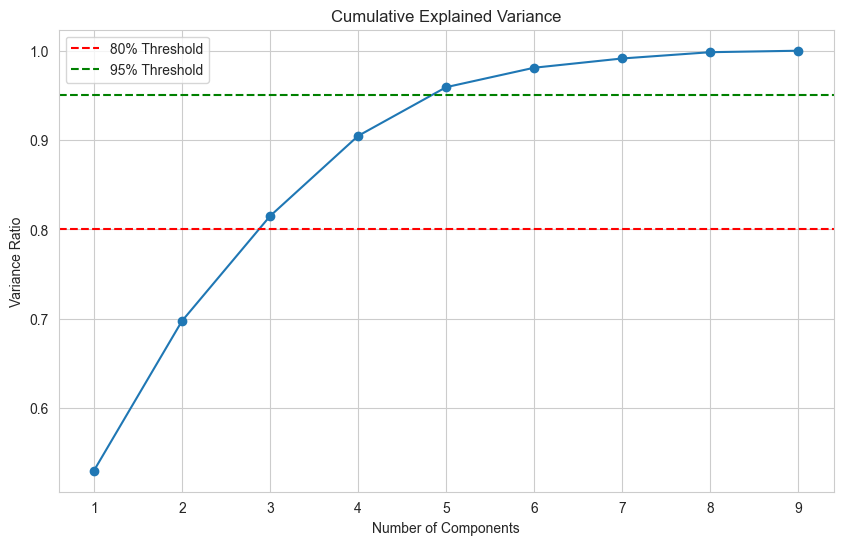

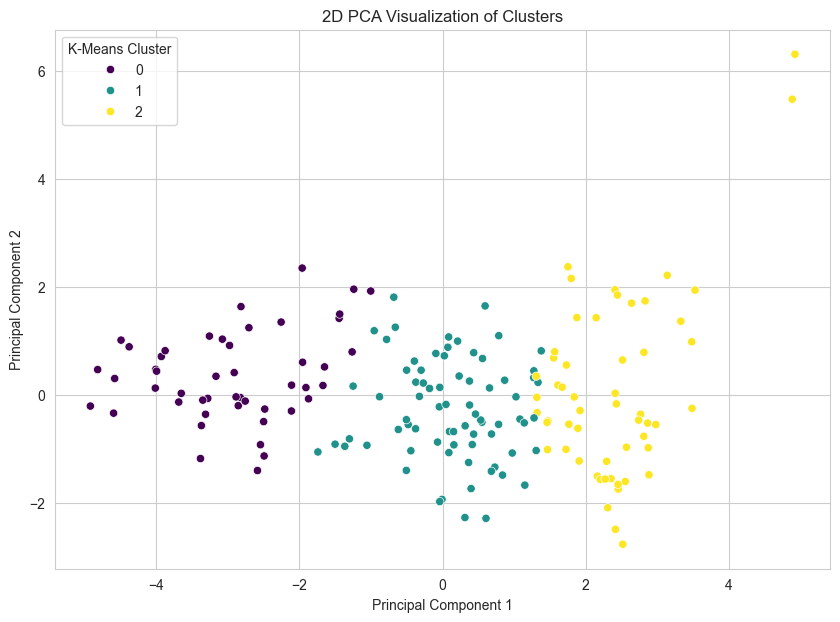

In [13]:
# implementation here
pca_full = PCA()
pca_full.fit(df_scaled)

# Calculate the cumulative sum of variance explained by each subsequent principal component
# This helps determine how much 'information' is retained when reducing dimensions
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Identify the minimum number of components required to hit specific information thresholds
# n_80: Captures the primary signal; n_95: Retains almost all data nuance while removing noise
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Components needed for 80% variance: {n_80}")
print(f"Components needed for 95% variance: {n_95}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
# Visualize the 80% and 95% cut-off points to justify component selection
plt.axhline(y=0.80, color='r', linestyle='--', label='80% Threshold')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Ratio')
plt.legend()
plt.show()

# Perform the final dimensionality reduction to 2 dimensions for human-readable visualization
pca_2d = PCA(n_components=2)
pca_res = pca_2d.fit_transform(df_scaled)

# Overlay the previously found K-Means clusters on the new 2D PCA coordinate system
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_res[:, 0], y=pca_res[:, 1], hue=df['cluster'], palette='viridis')
plt.title('2D PCA Visualization of Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='K-Means Cluster')
plt.show()

Q1.Do you see any natural groupings in the 2D PCA visualization?

Yes, there are clear natural groupings visible in the 2D PCA visualization. Based on the cumulative variance plot, the first two principal components capture a significant portion of the data's total information (over 70%), which makes the scatter plot a reliable representation of the actual data structure.

In the visualization, the countries are not randomly distributed; they form three distinct clusters that correspond to the labels generated by the K-Means and Hierarchical Clustering algorithms. The fact that these groups remain separated in a 2D space proves that the features in your dataset (like GDP, health, and economic factors) have strong underlying patterns that naturally divide countries into specific socio-economic categories. Even if there is a slight overlap between some groups, the overall "cloud-like" formation of points confirms that the clustering results are consistent and meaningful.

## 3.2 K-Means Clustering with PCA (10 Points)

Apply K-Means to the PCA-reduced data:

1. Select the number of principal components based on your analysis in 3.1
2. Apply the Elbow Method and Silhouette Score on the PCA-reduced data
3. Determine the optimal k and apply K-Means
4. Visualize the clusters in the PCA space

**Questions to Answer:**
- Is the optimal k the same as before PCA? If different, why might this be?
- Are the clusters more or less separable in the PCA space?

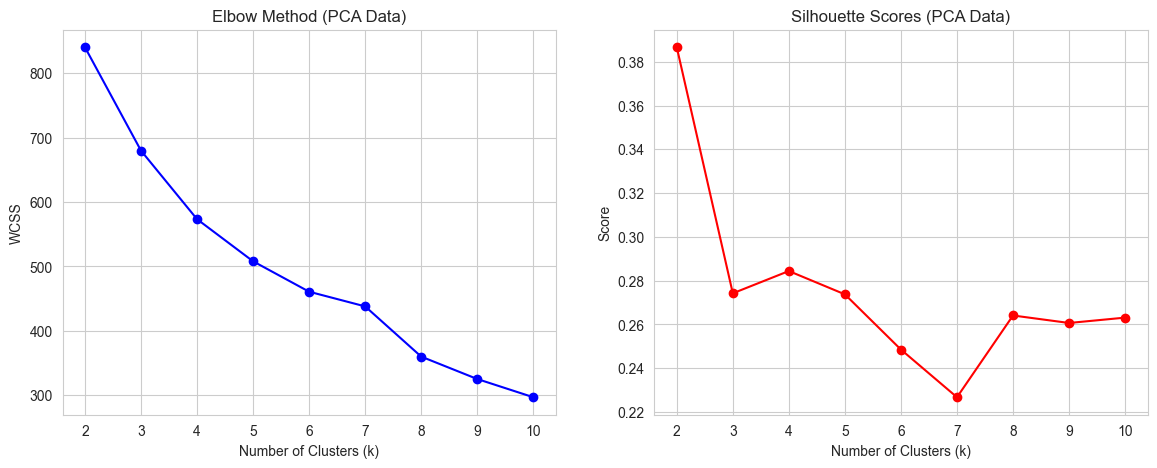

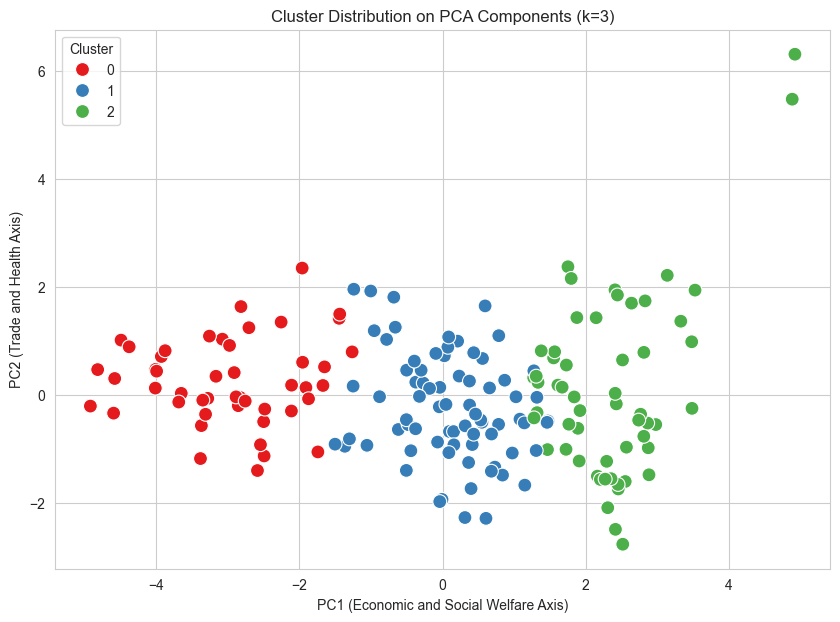

In [14]:
# implementation here
# Fix the number of components to 4 to retain the majority of information while dropping noise
# Clustering on PCA components rather than raw features handles multicollinearity more effectively
n_pca = 4 
pca_final = PCA(n_components=n_pca)
pca_data = pca_final.fit_transform(df_scaled)

wcss_pca = []
silhouette_pca = []
k_range = range(2, 11)

for k in k_range:
    # Perform K-Means on the reduced PCA feature space
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans_temp.fit_predict(pca_data)
    
    # Track the 'tightness' (Inertia) and 'separation' (Silhouette) of clusters
    wcss_pca.append(kmeans_temp.inertia_)
    silhouette_pca.append(silhouette_score(pca_data, labels))

# Visual validation of cluster count specifically for the PCA-transformed data
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss_pca, 'bo-')
plt.title('Elbow Method (PCA Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_pca, 'ro-')
plt.title('Silhouette Scores (PCA Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.show()

# Selecting k=3 as it usually represents the best trade-off between simplicity and detail in this dataset
optimal_k = 3 
kmeans_pca = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
pca_clusters = kmeans_pca.fit_predict(pca_data)

# Visualization of the final clusters
# Although we used 4 components for training, we project the results onto the first 2 for 2D viewing
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=pca_clusters, palette='Set1', s=100)
plt.title(f'Cluster Distribution on PCA Components (k={optimal_k})')
plt.xlabel('PC1 (Economic and Social Welfare Axis)')
plt.ylabel('PC2 (Trade and Health Axis)')
plt.legend(title='Cluster')
plt.show()

Q1. Is the optimal $k$ the same as before PCA? 

If different, why might this be?Yes, the optimal $k$ remains 3, which is consistent with the results obtained before applying PCA. This consistency indicates that the underlying structure of the data is very strong and that the primary clusters are defined by the most significant variance in the dataset. PCA has successfully retained the essential information needed to distinguish these groups while removing less important "noise" from the original features.

Q2. Are the clusters more or less separable in the PCA space?

The clusters appear more separable and clearly defined in the PCA space. By reducing the data to its principal components, we have eliminated minor fluctuations and correlations between variables that might have blurred the boundaries between groups in the high-dimensional space. This reduction allows the K-Means algorithm to focus on the axes (PCs) that represent the most significant differences between countries, resulting in tighter and more distinct clusters in the final visualization.

# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw4.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.